In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [155]:
wi_df = pd.read_csv("electricity_usage.csv")
ng_df = pd.read_csv("electricity_usage2.csv")

In [156]:
wi_df.head()

,연/월,전기사용량,실제요금
0,25년 3월,76,1962
1,25년 4월,132,3536
2,25년 5월,155,4504
3,25년 6월,133,3804
4,25년 7월,216,6446


In [157]:
ng_df.head()

,연/월,전기사용량,실제요금
0,25년 3월,32,810
1,25년 4월,110,2928
2,25년 5월,72,2121
3,25년 6월,76,2227
4,25년 7월,135,3868


In [158]:
def show_electricity_usage(df):
    fig, ax1 = plt.subplots(figsize=(12, 8))
    plt.title("연간 월별 전력사용량 및 전기요금", fontsize=14, pad=20)

    bars = ax1.bar(df.index, df["전기사용량"], color="blue", alpha=0.7, label="전력소비량 (kWh)")
    ax1.set_ylabel('월별 전기소비량 (kWh)', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()
    line = ax2.plot(df.index, df["실제요금"], color="red", marker='o', linewidth=2, label="전기요금 (엔)")
    ax2.set_ylabel('전기요금 (엔)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    plt.xticks(df.index, df["연/월"], rotation=90)

    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

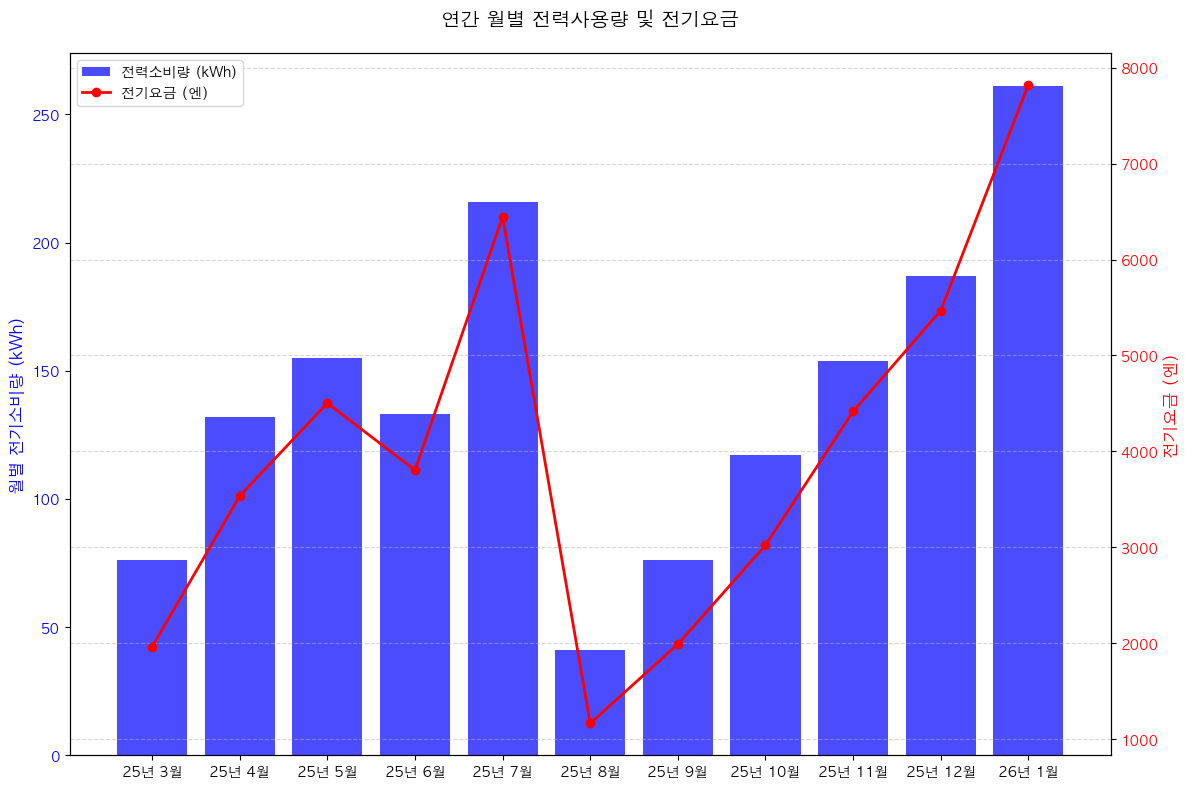

In [159]:
show_electricity_usage(wi_df)

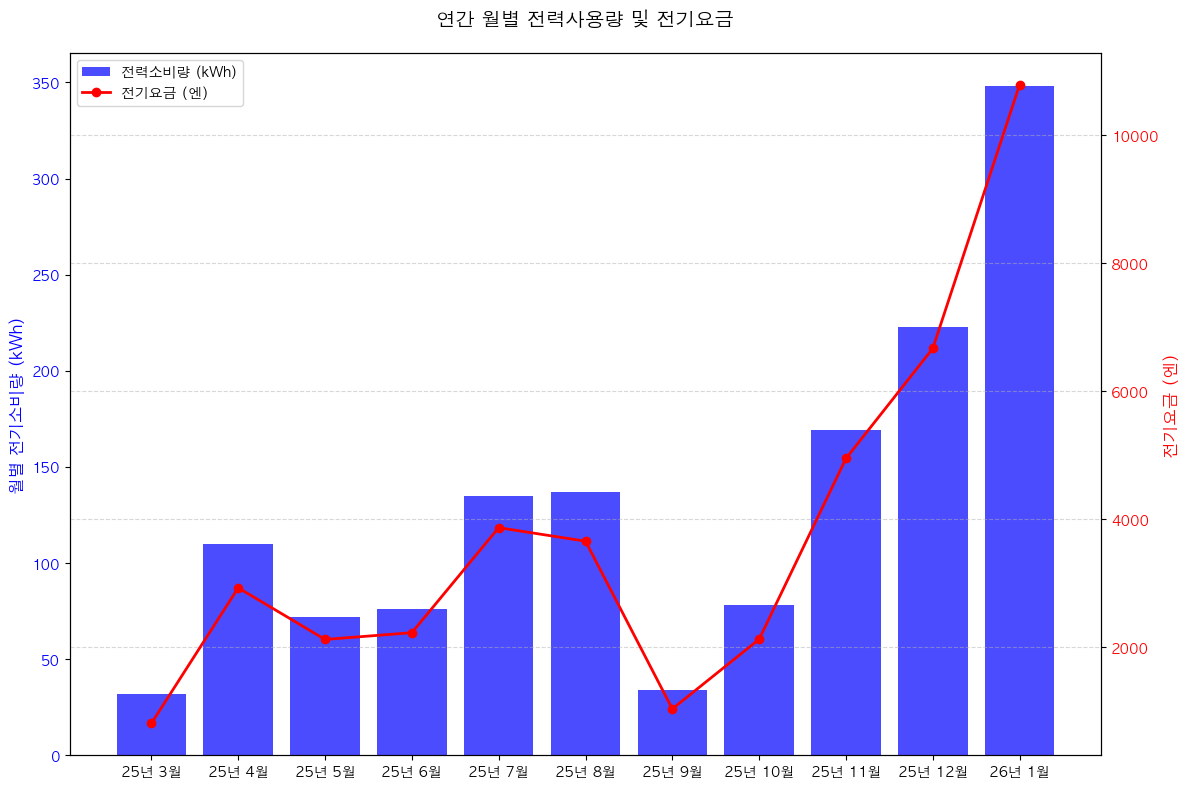

In [160]:
show_electricity_usage(ng_df)

In [ ]:
days_map = {
    '1월': 31, '2월': 28, '3월': 31, '4월': 30, '5월': 31, '6월': 30,
    '7월': 31, '8월': 31, '9월': 30, '10월': 31, '11월': 30, '12월': 31
}

def kansai_denryoku(row):
    '''간사이전력의 종량전등A 요금제'''
    base_fee = 522.58
    
    usage = row['전기사용량']
    energy_charge = 0
    
    if usage <= 15:
        energy_charge = 0
    elif usage <= 120:
        energy_charge = (usage - 15) * 20.21
    elif usage <= 300:
        energy_charge = (105 * 20.21) + (usage - 120) * 25.61
    else:
        energy_charge = (105 * 20.21) + (180 * 25.61) + (usage - 300) * 28.59
        
    return base_fee + energy_charge

def green_octopus(row):
    '''옥토퍼스 에너지의 그린 옥토퍼스 요금제'''
    month_text = row['연/월'].split(' ')[1]
    days = days_map.get(month_text, 30)
    
    base_fee = 12.40 * days
    
    usage = row['전기사용량']
    energy_charge = 0
    
    if usage <= 15:
        energy_charge = 0
    elif usage <= 120:
        energy_charge = (usage - 15) * 20.08
    elif usage <= 300:
        energy_charge = (105 * 20.08) + (usage - 120) * 22.7
    else:
        energy_charge = (105 * 20.08) + (180 * 22.7) + (usage - 300) * 262.61
        
    return base_fee + energy_charge

def simple_octopus(row):
    '''옥토퍼스 에너지의 심플 옥토퍼스 요금제'''
    usage = row["전기사용량"]
    return usage * 26.4

def au_denki(row):
    '''au전기의 덴키M플랜(관서) 요금제'''
    base_fee = 522.57
    
    usage = row['전기사용량']
    energy_charge = 0
    
    if usage <= 15:
        energy_charge = 0
    elif usage <= 120:
        energy_charge = (usage - 15) * 20.20
    elif usage <= 300:
        energy_charge = (105 * 20.20) + (usage - 120) * 25.60
    else:
        energy_charge = (105 * 20.20) + (180 * 25.60) + (usage - 300) * 28.58
        
    return base_fee + energy_charge

def softbank_denki(row):
    '''소프트뱅크 전기의 우리집 전기 Powered by 간사이전력 요금제'''
    base_fee = 522.58
    
    usage = row['전기사용량']
    energy_charge = 0
    
    if usage <= 15:
        energy_charge = 0
    elif usage <= 120:
        energy_charge = (usage - 15) * 20.21
    elif usage <= 300:
        energy_charge = (105 * 20.21) + (usage - 120) * 25.61
    else:
        energy_charge = (105 * 20.21) + (180 * 25.61) + (usage - 300) * 28.59
        
    return base_fee + energy_charge

In [162]:
plans = {
    "간사이전력, 종량전등A" : kansai_denryoku,
    "옥토퍼스 에너지, 그린 옥토퍼스" : green_octopus,
    "옥토퍼스 에너지, 심플 옥토퍼스" : simple_octopus,
    "au전기, 전기M플랜(관서)": au_denki,
    "소프트뱅크 전기, 우리집 전기 Powered by 간사이전력" : softbank_denki
}

In [163]:
def convert(df):
    for name, func in plans.items():
        df[name] = df.apply(func, axis=1)

In [164]:
comparison_list = ["실제요금"]
comparison_list.extend(list(plans.keys()))

In [165]:
def calc_and_show_prices(df):
    df_compare = df.melt(id_vars='연/월', 
                     value_vars=comparison_list,
                     var_name='요금제', 
                     value_name='금액')
    
    plt.figure(figsize=(15, 8))

    ax = sns.barplot(data=df_compare, x='연/월', y='금액', hue='요금제')

    plt.title("요금비교", fontsize=16)
    plt.ylabel("요금 (엔)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

In [166]:
convert(wi_df)
convert(ng_df)

In [167]:
wi_df.head()

,연/월,전기사용량,실제요금,"간사이전력, 종량전등A","옥토퍼스 에너지, 그린 옥토퍼스","옥토퍼스 에너지, 심플 옥토퍼스","au전기, 전기M플랜(관서)","소프트뱅크 전기, 우리집 전기 Powered by 간사이전력"
0,25년 3월,76,1962,1755.39,1609.28,2006.4,1754.77,1755.39
1,25년 4월,132,3536,2951.95,2752.80,3484.8,2950.77,2951.95
2,25년 5월,155,4504,3540.98,3287.30,4092.0,3539.57,3540.98
3,25년 6월,133,3804,2977.56,2775.50,3511.2,2976.37,2977.56
4,25년 7월,216,6446,5103.19,4672.00,5702.4,5101.17,5103.19


In [168]:
ng_df.head()

,연/월,전기사용량,실제요금,"간사이전력, 종량전등A","옥토퍼스 에너지, 그린 옥토퍼스","옥토퍼스 에너지, 심플 옥토퍼스","au전기, 전기M플랜(관서)","소프트뱅크 전기, 우리집 전기 Powered by 간사이전력"
0,25년 3월,32,810,866.15,725.76,844.8,865.97,866.15
1,25년 4월,110,2928,2442.53,2279.60,2904.0,2441.57,2442.53
2,25년 5월,72,2121,1674.55,1528.96,1900.8,1673.97,1674.55
3,25년 6월,76,2227,1755.39,1596.88,2006.4,1754.77,1755.39
4,25년 7월,135,3868,3028.78,2833.30,3564.0,3027.57,3028.78


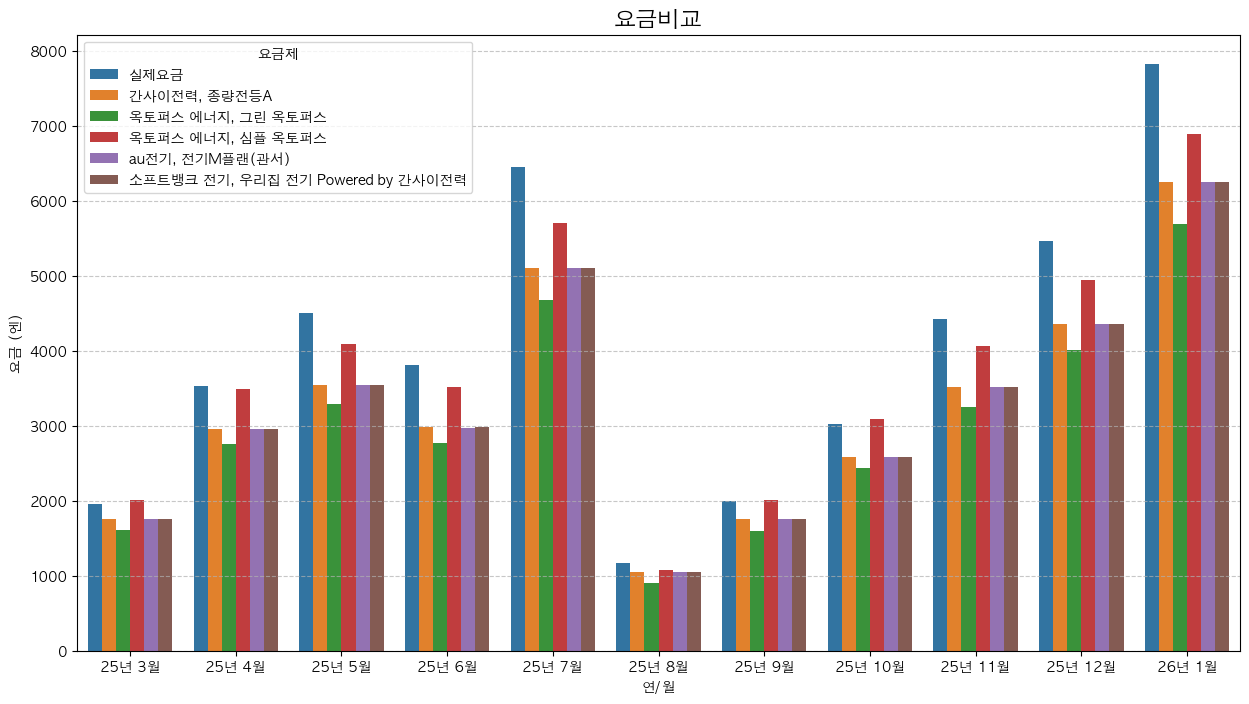

In [169]:
calc_and_show_prices(wi_df)

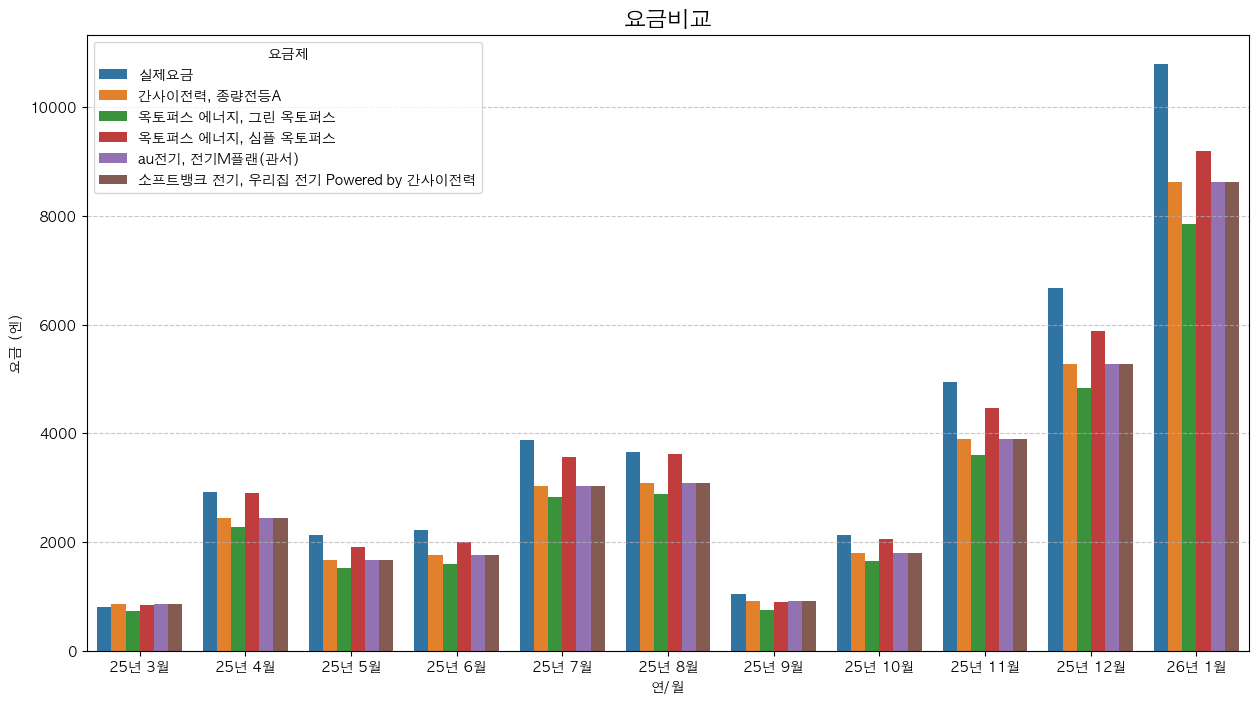

In [170]:
calc_and_show_prices(ng_df)

In [171]:
months = 11

In [172]:
phone_plans = {
    "Rakuten Mobile, Rakuten 최강 플랜" : 1980 * months,
    "UQ Mobile, 코미코미플랜 밸류" : 3278 * months,
    "UQ Mobile, 토쿠토쿠플랜2" : 4048 * months,
    "UQ Mobile, 토쿠토쿠플랜2 + 전기 할인" : (2398 + 550) * months,
    "UQ Mobile, 토쿠토쿠플랜2 + 가족할인" : (2398 + 1100) * months,
    "UQ Mobile, 토쿠토쿠플랜2 + 전기 할인 + 가족할인" : 2398 * months,
    "NTT도코모, ahamo" : 2970 * months,
    "Y!Mobile, 심플3M" : 4158 * months,
    "Y!Mobile, 심플3M + 전기 할인" : 3058 * months,
    "LINEMO, 베스트 플랜 V" : 2970 * months
}

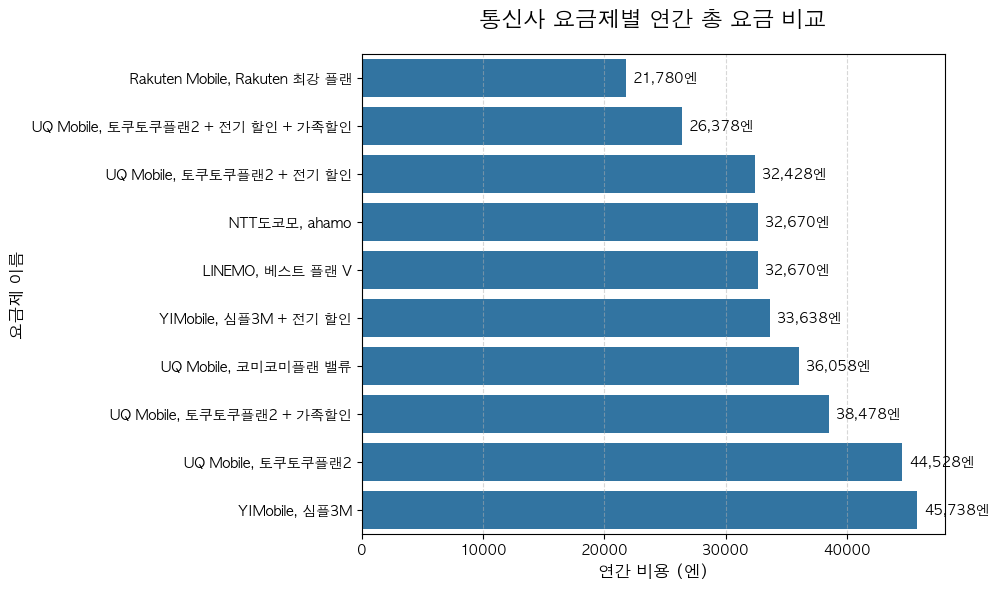

In [175]:
phone_plans_df = pd.DataFrame(list(phone_plans.items()), columns=['요금제', '연간비용'])
phone_plans_df = phone_plans_df.sort_values(by='연간비용')

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=phone_plans_df, x='연간비용', y='요금제')

plt.title('통신사 요금제별 연간 총 요금 비교', fontsize=16, pad=20)
plt.xlabel('연간 비용 (엔)', fontsize=12)
plt.ylabel('요금제 이름', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}엔', 
                (p.get_width(), p.get_y() + p.get_height() / 2), 
                ha='left', va='center', xytext=(5, 0), 
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
total_spending = {
    "간사이전력, 종량전등A / Rakuten Mobile, Rakuten 최강 플랜" : wi_df["실제요금"].sum() + phone_plans["Rakuten Mobile, Rakuten 최강 플랜"],
    "옥토퍼스 에너지, 그린 옥토퍼스 / NTT도코모, ahamo" :  wi_df["옥토퍼스 에너지, 그린 옥토퍼스"].sum() + phone_plans["NTT도코모, ahamo"],
    "au전기, 전기M플랜(관서) / UQ Mobile, 토쿠토쿠플랜2 + 전기 할인 + 가족할인" : wi_df["실제요금"].sum() + phone_plans["UQ Mobile, 토쿠토쿠플랜2 + 전기 할인 + 가족할인"],
    "au전기, 전기M플랜(관서) / UQ Mobile, 토쿠토쿠플랜2 + 전기 할인" : wi_df["실제요금"].sum() + phone_plans["UQ Mobile, 토쿠토쿠플랜2 + 전기 할인"]
}

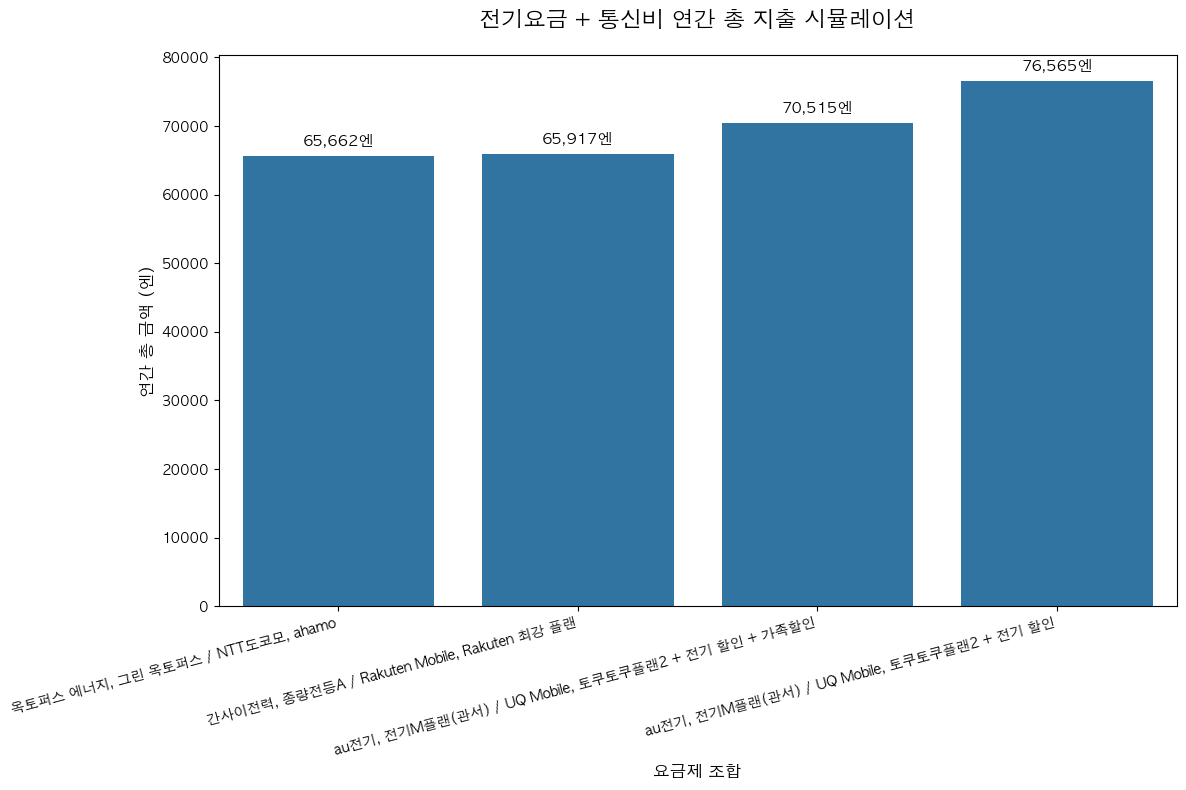

In [ ]:
spending_df = pd.DataFrame(list(total_spending.items()), columns=['조합', '총지출'])
spending_df = spending_df.sort_values(by='총지출')

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=spending_df, x='조합', y='총지출')

plt.title("전기요금 + 통신비 연간 총 지출 시뮬레이션", fontsize=16, pad=20)
plt.ylabel("연간 총 금액 (엔)", fontsize=12)
plt.xlabel("요금제 조합", fontsize=12)

plt.xticks(rotation=15, ha='right')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}엔', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()